In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as sps
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

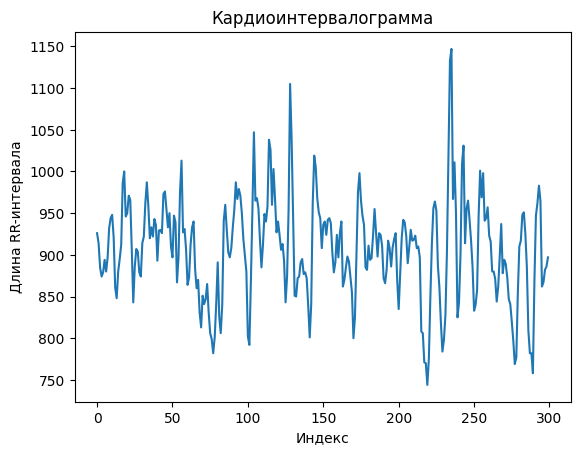

In [ ]:
# Загружаем данные из CSV-файла
data = pd.read_csv("/3_f_1.csv", header=None)

# Извлекаем значения из столбца
values = data.values.flatten()

# Создаем массив индексов
indices = range(len(values))

# Строим график
plt.plot(indices, values)

# Настраиваем заголовки осей
plt.xlabel("Индекс")
plt.ylabel("Длина RR-интервала")

# Добавляем заголовок графика
plt.title("Кардиоинтервалограмма")

# Отображаем график
plt.show()

In [ ]:
def find_nn_intervals(rr_intervals):

  # 1. Вычисляем порог для определения экстрасистол
  threshold = np.mean(rr_intervals) * 1.5  # 1.5 - эмпирическое значение

  # 2. Находим NN-интервалы, исключая экстрасистолы
  nn_intervals = []
  for i in range(len(rr_intervals) - 1):
    if rr_intervals[i] < threshold and rr_intervals[i + 1] < threshold:
      nn_intervals.append(rr_intervals[i])

  return np.array(nn_intervals)

In [ ]:
def sum_of_squares_difference(arr):

  # Создаем массив разностей
  differences = np.diff(arr)

  # Вычисляем сумму квадратов разностей
  sum_of_squares = np.sum(differences**2)

  return sum_of_squares

In [ ]:
#Частота сердечных сокращений
nn_values = find_nn_intervals(values)
chss = 60 * 1000 * len(values) / sum(nn_values)
print("Частота сердечных сокращений: ", chss)

#Среднее значение
median = sum(values)/len(values)
print("Среднее значение: ", median)

#Стандартное отклонение (SDNN)
sdnn = ((1/(len(values)-1))*sum_of_squares_difference(nn_values))**(1/2)
print("Стандартное отклонение (SDNN): ", sdnn)

#Коэффициент вариации (CV)
cv = sdnn/median * 100
print("Коэффициент вариации (CV): ", cv)

#Среднеквадратическую разностную характеристику RMSSD
rmssd = ((1/(len(values)-1))*sum((values-median)**2))**(1/2)
print("Среднеквадратическую разностную характеристику RMSSD: ", rmssd)

Частота сердечных сокращений:  66.4071867333198
Среднее значение:  906.5066666666667
Стандартное отклонение (SDNN):  42.25832327823272
Коэффициент вариации (CV):  4.6616671263567895
Среднеквадратическую разностную характеристику RMSSD:  60.81522501975059


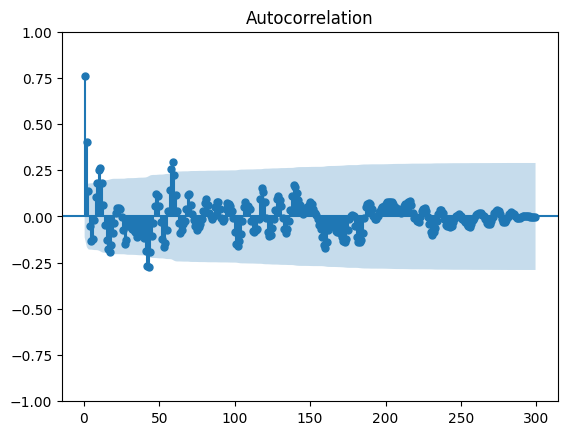

In [ ]:
#Построение графика автокоррелограммы
acf_result = sm.tsa.acf(np.array(values))
sm.graphics.tsa.plot_acf(data, lags=range(1, len(data)))
plt.show()

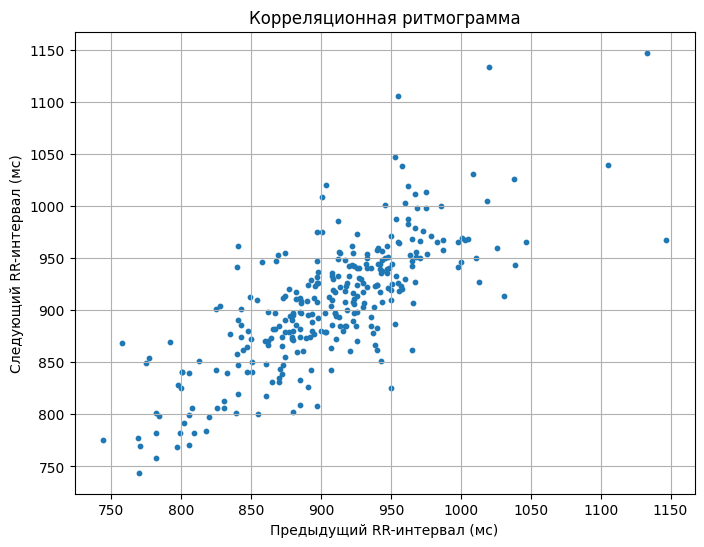

Вариабельность сердечного ритма в пределах нормы.


In [ ]:
def plot_correlogram(rr_intervals):

  # Создаем массив предыдущих RR-интервалов
  previous_rr = rr_intervals[:-1]

  # Создаем массив следующих RR-интервалов
  next_rr = rr_intervals[1:]

  # Строим график
  plt.figure(figsize=(8, 6))
  plt.scatter(previous_rr, next_rr, s=10)
  plt.xlabel("Предыдущий RR-интервал (мс)")
  plt.ylabel("Следующий RR-интервал (мс)")
  plt.title("Корреляционная ритмограмма")
  plt.grid(True)
  plt.show()

def analyze_correlogram(rr_intervals):

  # Вычисляем стандартное отклонение RR-интервалов
  std_dev = np.std(rr_intervals)

  # Вычисляем коэффициент вариации RR-интервалов
  cv = std_dev / np.mean(rr_intervals)

  # Анализируем корреляционную ритмограмму
  if cv > 0.15:
    return "Обнаружена высокая вариабельность сердечного ритма, возможно наличие аритмии."
  else:
    return "Вариабельность сердечного ритма в пределах нормы."


# Строим корреляционную ритмограмму
plot_correlogram(values)

# Анализируем корреляционную ритмограмму
analysis_result = analyze_correlogram(values)
print(analysis_result)

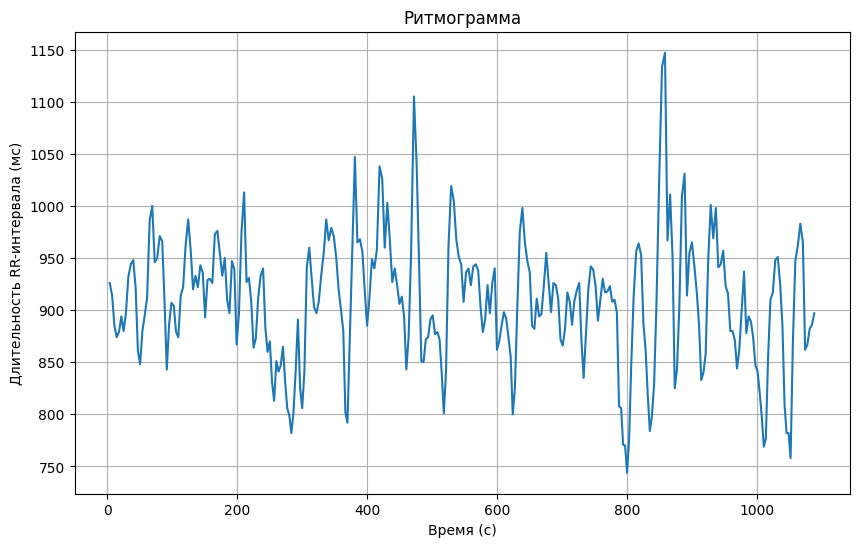

In [ ]:
def plot_rhythmogram(rr_intervals, sampling_rate):

  # Вычисляем время появления каждого RR-интервала
  times = np.cumsum(rr_intervals) / sampling_rate

  # Строим график
  plt.figure(figsize=(10, 6))
  plt.plot(times, rr_intervals)
  plt.xlabel("Время (с)")
  plt.ylabel("Длительность RR-интервала (мс)")
  plt.title("Ритмограмма")
  plt.grid(True)
  plt.show()

sampling_rate = 250  # Частота дискретизации (Гц)

# Строим ритмограмму
plot_rhythmogram(values, sampling_rate)

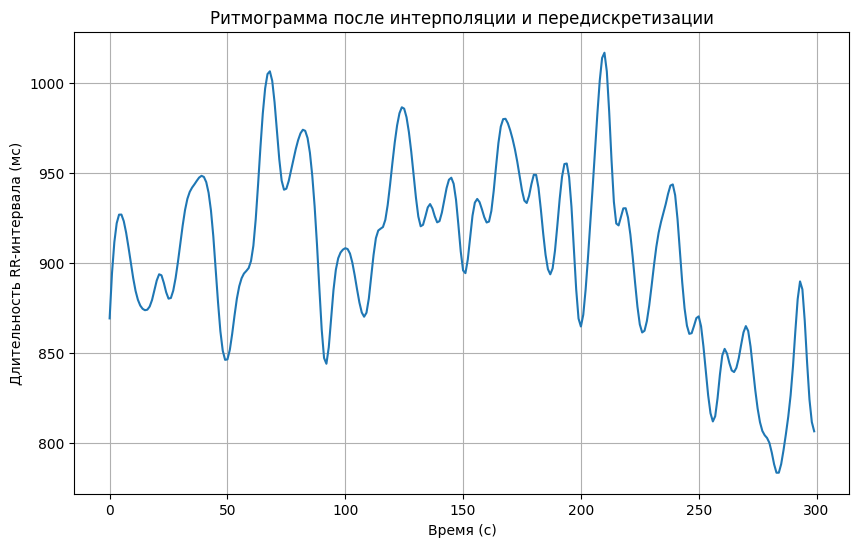

In [ ]:
from scipy.interpolate import CubicSpline
import numpy as np
import matplotlib.pyplot as plt

def interpolate_and_resample(rr_intervals, sampling_rate, new_sampling_rate):

  # Вычисляем время появления каждого RR-интервала
  times = np.cumsum(rr_intervals) / sampling_rate

  # Проводим кубическую интерполяцию
  cs = CubicSpline(times, rr_intervals)

  # Создаем новый массив времени с постоянным шагом
  new_times = np.arange(0, times[-1], 1/new_sampling_rate)

  # Передискретизируем кривую
  new_rr_intervals = cs(new_times)

  # Определяем размерность исходных данных
  original_size = len(rr_intervals)

  # Пересчитываем new_rr_intervals
  new_rr_intervals = np.interp(np.arange(original_size), np.linspace(0, len(new_rr_intervals), num=len(new_rr_intervals)), new_rr_intervals)

  return new_rr_intervals

sampling_rate = 250  # Исходная частота дискретизации (Гц)
new_sampling_rate = 1  # Новая частота дискретизации (Гц)

# Проводим интерполяцию и передискретизацию
new_rr_intervals = interpolate_and_resample(values, sampling_rate, new_sampling_rate)

# Вычисляем время появления каждого RR-интервала для новой частоты дискретизации
new_times = np.arange(0, len(new_rr_intervals) / new_sampling_rate, 1/new_sampling_rate)

# Строим график
plt.figure(figsize=(10, 6))
plt.plot(new_times, new_rr_intervals)
plt.xlabel("Время (с)")
plt.ylabel("Длительность RR-интервала (мс)")
plt.title("Ритмограмма после интерполяции и передискретизации")
plt.grid(True)
plt.show()


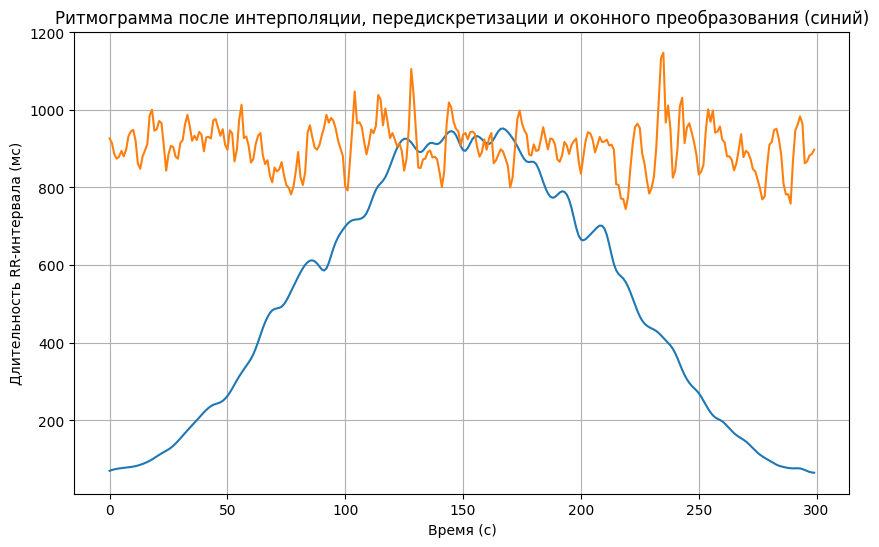

In [ ]:
from scipy.signal import get_window

window_type = 'hamming'  # Тип оконной функции
window_size = 300  # Размер окна

# Применяем оконную функцию
window = get_window(window_type, window_size)
windowed_signal = new_rr_intervals * window

# Вычисляем время появления каждого RR-интервала для новой частоты дискретизации
new_times = np.arange(0, len(windowed_signal) / new_sampling_rate, 1/new_sampling_rate)

# Строим график
plt.figure(figsize=(10, 6))
plt.plot(new_times, windowed_signal)
plt.plot(new_times, values)
plt.xlabel("Время (с)")
plt.ylabel("Длительность RR-интервала (мс)")
plt.title("Ритмограмма после интерполяции, передискретизации и оконного преобразования (синий)")
plt.grid(True)
plt.show()

In [ ]:
from scipy.fft import fft, fftfreq
from scipy.signal import get_window

def calculate_power_spectrum(rr_intervals, sampling_rate, window_type='hamming'):

  # Вычисляем быстрое преобразование Фурье
  fft_result = fft(windowed_signal)

  # Получаем частоты
  frequencies = fftfreq(len(rr_intervals), d=1/sampling_rate)

  # Вычисляем мощность спектра
  power_spectrum = np.abs(fft_result)**2

  # Определяем границы частотных диапазонов
  vlf_low, vlf_high = 0.003, 0.04
  lf_low, lf_high = 0.04, 0.15
  hf_low, hf_high = 0.15, 0.4

  # Вычисляем мощности в диапазонах
  vlf_power = np.trapz(power_spectrum[(frequencies >= vlf_low) & (frequencies < vlf_high)], x=frequencies[(frequencies >= vlf_low) & (frequencies < vlf_high)])
  lf_power = np.trapz(power_spectrum[(frequencies >= lf_low) & (frequencies < lf_high)], x=frequencies[(frequencies >= lf_low) & (frequencies < lf_high)])
  hf_power = np.trapz(power_spectrum[(frequencies >= hf_low) & (frequencies < hf_high)], x=frequencies[(frequencies >= hf_low) & (frequencies < hf_high)])

  # Возвращаем словарь с мощностями
  return {"VLF": vlf_power, "LF": lf_power, "HF": hf_power}

def analyze_vegetative_regulation(lf_power, hf_power):

  ivv = lf_power / hf_power

  if ivv < 0.5:
    return "Ваготония"
  elif 0.5 <= ivv <= 2:
    return "Нормотония"
  else:
    return "Симпатикотония"

# Вычисляем мощность спектра
power_spectrum = calculate_power_spectrum(new_rr_intervals, new_sampling_rate)

# Анализируем тип регуляции
regulation_type = analyze_vegetative_regulation(power_spectrum["LF"], power_spectrum["HF"])
print(f"Мощность спектра: {power_spectrum}")
print(f"Тип регуляции вегетативной нервной системы: {regulation_type}")


Мощность спектра: {'VLF': 7122504.907954049, 'LF': 28140.77756207544, 'HF': 58.054177055723926}
Тип регуляции вегетативной нервной системы: Симпатикотония
